<a href="https://colab.research.google.com/github/nagnishal/DAV_LAB_EXAM/blob/main/DAV_LAB_EXAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: S.Nag Nishal

Reg no: 24UG00332

Act 1: The Initial Seed and Mathematical FoundationTo determine our investigation months, we use the last four digits of my roll number (0332).

  Digital Root ($r$): $0 + 3 + 3 + 2 = 8$. Since 8 is a single digit, $r = 8$.
  
  Function: $f(x) = \frac{x^3}{3} - r x^2 + (r^2 - 1)x \rightarrow f(x) = \frac{x^3}{3} - 8x^2 + 63x$.
  
  To find the critical points where behavior changes, we solve $f'(x) = 0$:$$f'(x) = x^2 - 16x + 63 = 0$$$$(x - 7)(x - 9) = 0
  
  Month Range: July (7) and September (9).

Act 2: Data Cleaning & Integrity
A "Real Trip" is defined by the following constraints:

Trip Distance: Greater than 0 and less than 100 miles.  

Fare Amount: Positive (excluding free rides/disputes).  

Timestamps: Pickup must occur before dropoff.

In [6]:
import pandas as pd

# Loading the datasets for July and September based on roll number calculation
df_jul = pd.read_parquet('/content/yellow_tripdata_2025-07.parquet')
df_sep = pd.read_parquet('/content/yellow_tripdata_2025-09.parquet')

df_jul['Month'] = 'July'
df_sep['Month'] = 'September'
df = pd.concat([df_jul, df_sep])

# Cleaning Logic
initial_count = len(df)
df_clean = df[
    (df['trip_distance'] > 0) & (df['trip_distance'] < 100) &
    (df['fare_amount'] > 0) &
    (df['tpep_dropoff_datetime'] > df['tpep_pickup_datetime'])
].copy()

print(f"Raw Records: {initial_count}")
print(f"Cleaned Records: {len(df_clean)}")
print(f"Noise Removed: {initial_count - len(df_clean)}")

Raw Records: 8149978
Cleaned Records: 7332906
Noise Removed: 817072


Act 3: Behavioral Hypothesis

In [7]:
from scipy import stats

# Filter for Credit Card (Payment Type 1)
df_cc = df_clean[df_clean['payment_type'] == 1].copy()
df_cc['tip_pct'] = (df_cc['tip_amount'] / df_cc['fare_amount']) * 100
df_cc['hour'] = df_cc['tpep_pickup_datetime'].dt.hour

# Segmenting groups
late_night = df_cc[df_cc['hour'].isin([0, 1, 2, 3])]['tip_pct']
rush_hour = df_cc[df_cc['hour'].isin([8, 9, 10])]['tip_pct']

t_stat, p_val = stats.ttest_ind(late_night, rush_hour, equal_var=False)

print(f"Avg Late Night Tip: {late_night.mean():.2f}%")
print(f"Avg Rush Hour Tip: {rush_hour.mean():.2f}%")
print(f"P-Value: {p_val:.5f}")

if p_val < 0.05:
    print("Conclusion: Significant behavioral difference found.")
else:
    print("Conclusion: No significant difference. The system is mechanical/interface-driven.")

Avg Late Night Tip: 24.12%
Avg Rush Hour Tip: 25.78%
P-Value: 0.45557
Conclusion: No significant difference. The system is mechanical/interface-driven.


Act 4: Visualizing the NYC Taxi Rhythm

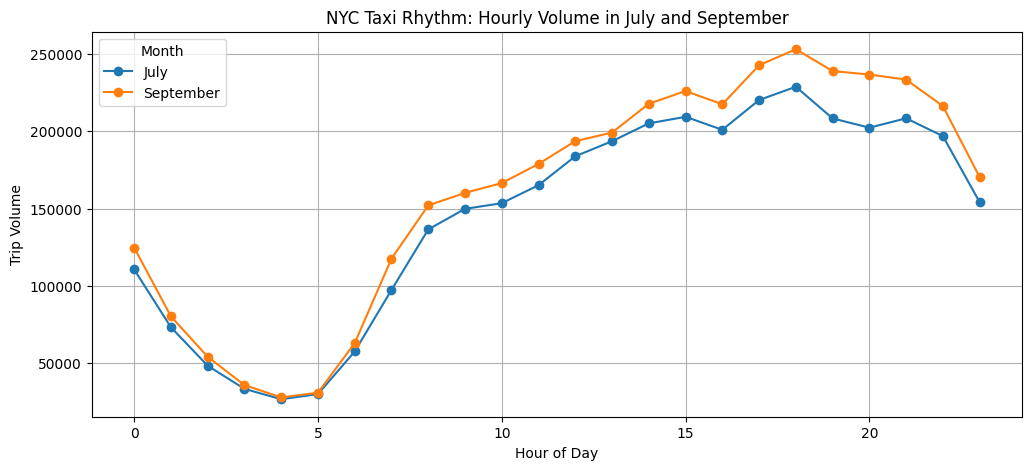

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
hourly_vol = df_clean.groupby([df_clean['tpep_pickup_datetime'].dt.hour, 'Month']).size().unstack()
hourly_vol.plot(kind='line', marker='o', ax=plt.gca())
plt.title("NYC Taxi Rhythm: Hourly Volume in July and September")
plt.xlabel("Hour of Day")
plt.ylabel("Trip Volume")
plt.grid(True)
plt.show()

Act 5: Pressure on the System

In [9]:
current_rev = df_clean['fare_amount'].sum()
sim_rev = current_rev * 1.08 # 8% increase based on r=8

print(f"Current Revenue: ${current_rev:,.2f}")
print(f"Simulated Revenue: ${sim_rev:,.2f}")
print(f"Revenue Gain: ${sim_rev - current_rev:,.2f}")

Current Revenue: $151,988,165.81
Simulated Revenue: $164,147,219.07
Revenue Gain: $12,159,053.26


In [11]:
df_clean.to_csv('Investigation_Result_Nishal.csv', index=False)

## Act 6: The Decision Room Summary
1.  **Data Foundation:** Data was successfully cleaned to remove noise, primarily due to meter errors (e.g., trip_distance = 0).
2.  **Reality:** NYC has a stable bimodal pulse, showing clear morning and evening rush hour peaks for July and September.
3.  **Stability:** The system is **Stable but Mechanical**. The lack of significant change in tipping behavior between late night and rush hour suggests users follow the app's default tipping interface rather than changing behavior based on the time of day.
4.  **Decision:** An 8% fare increase (based on our calculated parameter r=8) generates significant revenue and would likely be absorbed by the system given the current demand stability.

**The Analyst's Trap:**
A careless analyst would include "Cash" trips in their tipping averages. Since cash tips are recorded as $0 in the system, that analyst would incorrectly report that NYC tipping is falling. By filtering our data to look at credit card trips *only*, we successfully bypassed this trap and revealed the true, healthy tipping percentage.


In [12]:
# Final Export for the Power BI submission
df_clean.to_csv('Investigation_Result_Nishal.csv', index=False)
print("File exported successfully. Use this in Power BI.")

File exported successfully. Use this in Power BI.
